# Lab 4 Geographical Data

### Imports

In [1]:
import matplotlib.pyplot as plt
import geopandas
import numpy as np
import pandas as pd
import seaborn as sns
states = geopandas.read_file('data1/cb_2020_us_cousub_500k/cb_2020_us_cousub_500k.shp')

### Sample Data

In [3]:
states.head()

,STATEFP,COUNTYFP,COUSUBFP,COUSUBNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,29,195,22096,00767361,0600000US2919522096,2919522096,Elmwood,Elmwood township,MO,Saline County,Missouri,44,181233131,377337,"POLYGON ((-93.48978 39.06658, -93.48938 39.073..."
1,38,099,45260,01036531,0600000US3809945260,3809945260,Latona,Latona township,ND,Walsh County,North Dakota,44,90848624,2941846,"POLYGON ((-98.16255 48.36954, -98.05746 48.369..."
2,38,017,16100,01036391,0600000US3801716100,3801716100,Cornell,Cornell township,ND,Cass County,North Dakota,44,93440087,0,"POLYGON ((-97.70538 47.04981, -97.70558 47.051..."
3,38,093,22940,01036472,0600000US3809322940,3809322940,Eldridge,Eldridge township,ND,Stutsman County,North Dakota,44,90001176,2572532,"POLYGON ((-98.94567 46.97918, -98.85914 46.979..."
4,38,079,67780,01036243,0600000US3807967780,3807967780,Rolette,Rolette city,ND,Rolette County,North Dakota,25,2609731,0,"POLYGON ((-99.85266 48.6682, -99.83068 48.6681..."


In [5]:
states.crs #Coordinate Reference System

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [7]:
states = states.to_crs("EPSG:3395")

### Visualize Map of United States

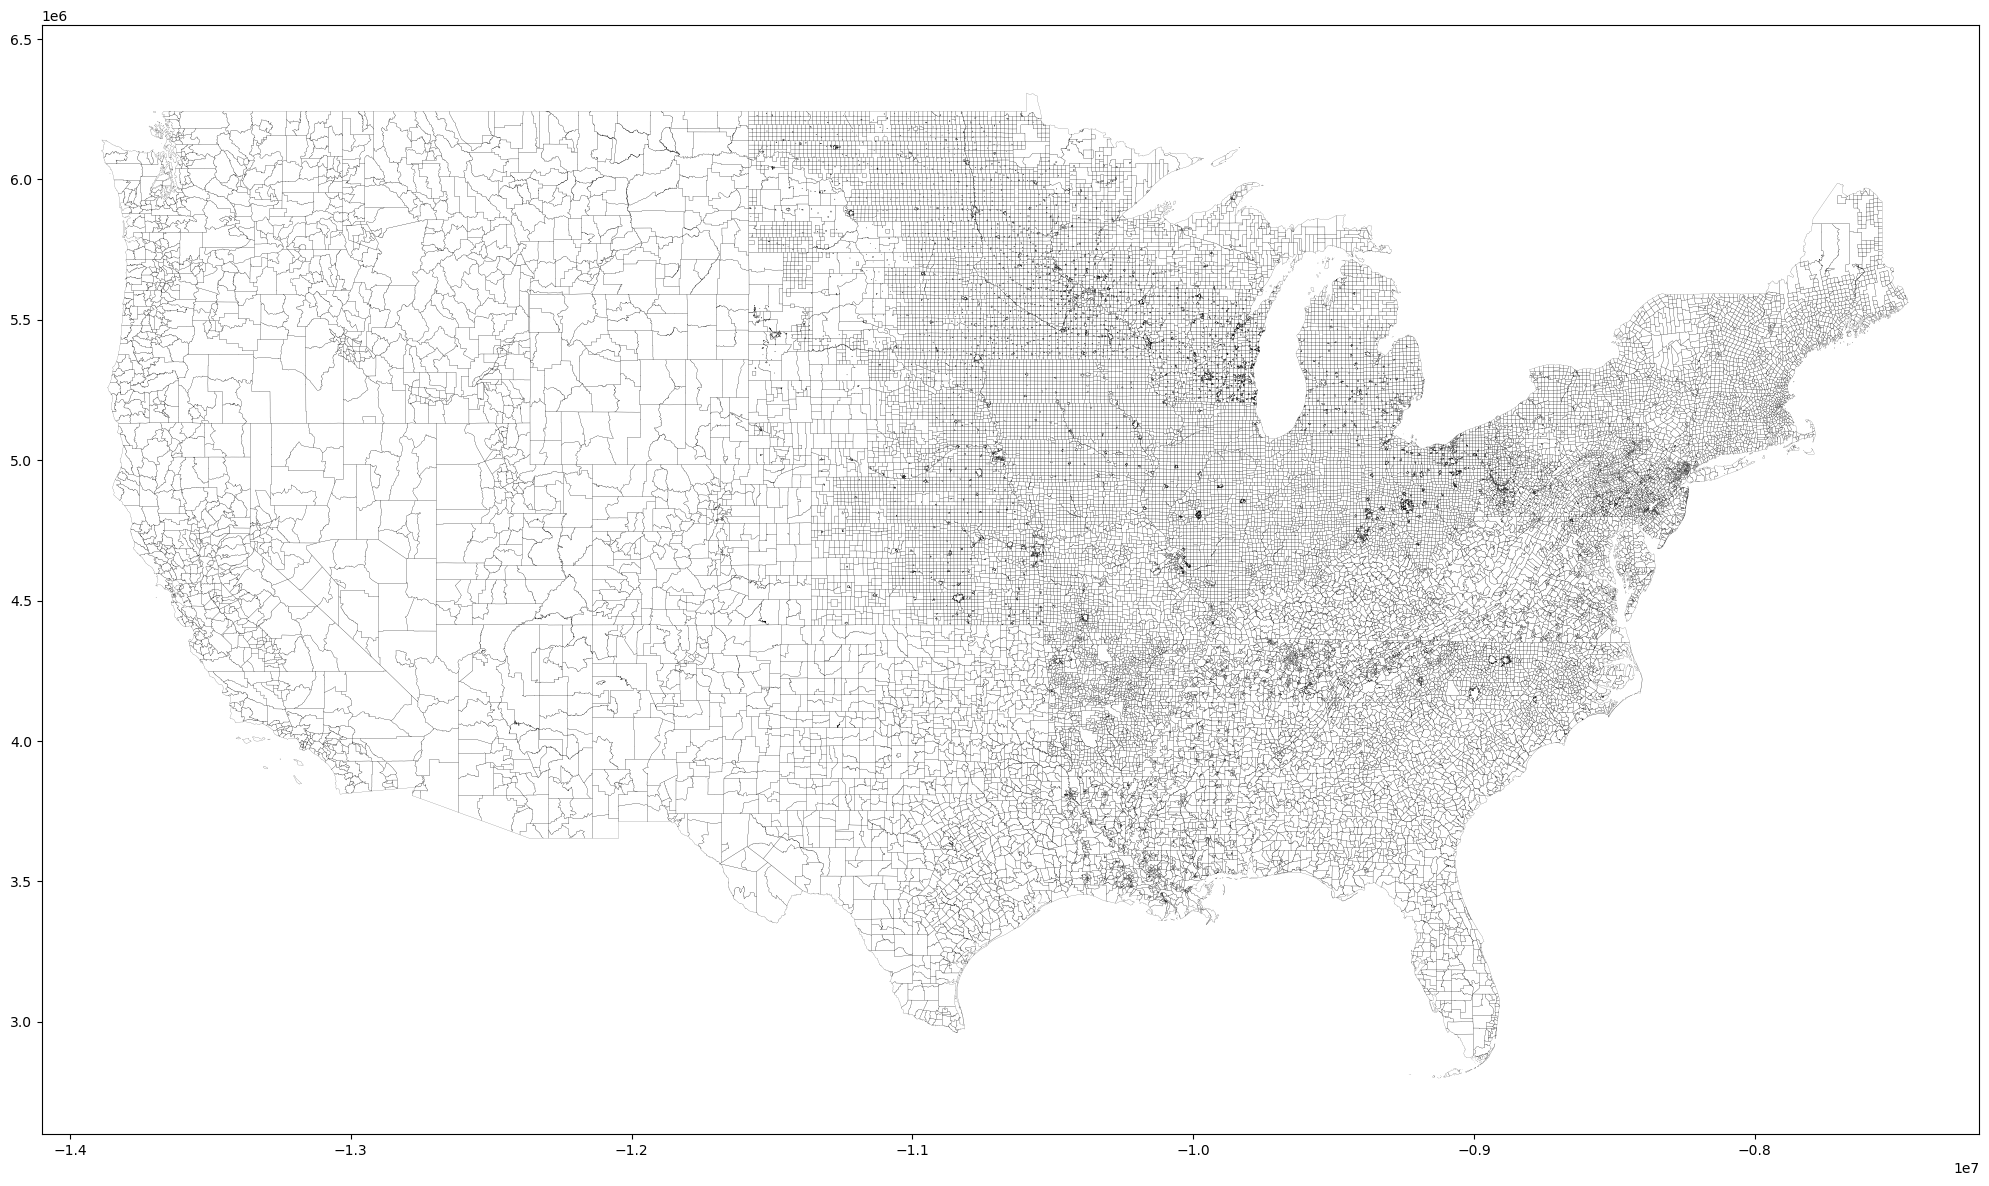

In [9]:
fig = plt.figure(1, figsize=(25,15)) 
ax = fig.add_subplot()
# Plot only 48 states
ax.set_xlim(-14100244, -7200000)
ax.set_ylim(2600000, 6550000)
states.boundary.plot(ax = ax, color = 'black', linewidth = .1)
# Save fig
fig.savefig('RubyUSMap.png')

### Visualize Water Area of United States

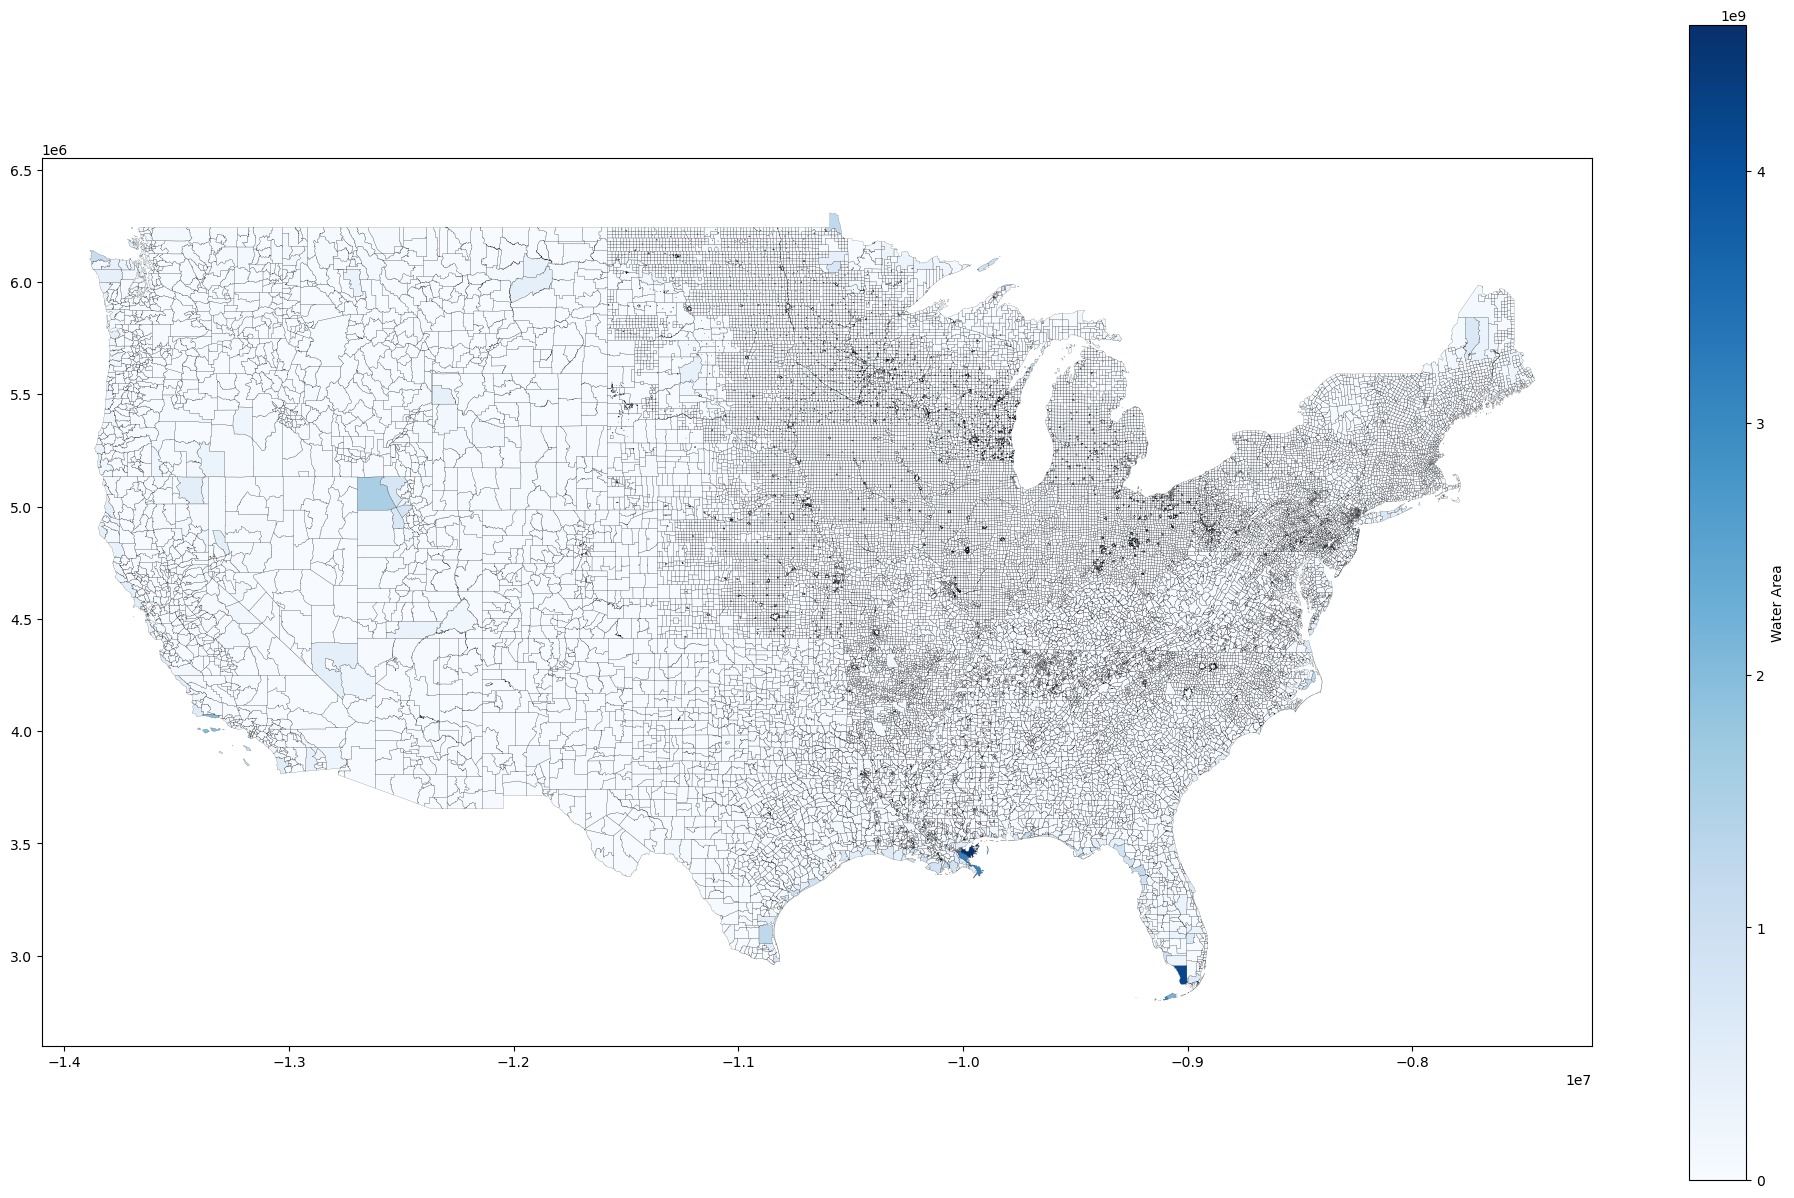

In [11]:
contiguous = states[~states['STATE_NAME'].isin(['Alaska', 'Hawaii'])]
fig = plt.figure(1, figsize=(25,15)) 
ax = fig.add_subplot()
ax.set_xlim(-14100244, -7200000)
ax.set_ylim(2600000, 6550000)
contiguous.boundary.plot(ax = ax, color = 'black', linewidth = .1)
contiguous.plot(ax = ax, column = 'AWATER', cmap = 'Blues', legend = True, legend_kwds = {'label': "Water Area"})
# Save fig
fig.savefig('RubyUSWater.png')

### Get Tornado Data

In [13]:
tornados = geopandas.read_file('zip://data1/1950-2018-torn-initpoint.zip!1950-2018-torn-initpoint')

In [15]:
tornados.shape

(63645, 23)

In [17]:
tornados.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 63645 entries, 0 to 63644
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   om        63645 non-null  int64   
 1   yr        63645 non-null  int64   
 2   mo        63645 non-null  int64   
 3   dy        63645 non-null  int64   
 4   date      63645 non-null  object  
 5   time      63645 non-null  object  
 6   tz        63645 non-null  int64   
 7   st        63645 non-null  object  
 8   stf       63645 non-null  int64   
 9   stn       63645 non-null  int64   
 10  mag       63645 non-null  int64   
 11  inj       63645 non-null  int64   
 12  fat       63645 non-null  int64   
 13  loss      63645 non-null  float64 
 14  closs     63645 non-null  float64 
 15  slat      63645 non-null  float64 
 16  slon      63645 non-null  float64 
 17  elat      63645 non-null  float64 
 18  elon      63645 non-null  float64 
 19  len       63645 non-null  float64 
 20

In [19]:
tornados.head()

,om,yr,mo,dy,date,time,tz,st,stf,stn,...,loss,closs,slat,slon,elat,elon,len,wid,fc,geometry
0,1,1950,1,3,1950-01-03,11:00:00,3,MO,29,1,...,6.0,0.0,38.77,-90.22,38.8300,-90.0300,9.5,150,0,POINT (-90.22 38.77)
1,2,1950,1,3,1950-01-03,11:55:00,3,IL,17,2,...,5.0,0.0,39.10,-89.30,39.1200,-89.2300,3.6,130,0,POINT (-89.3 39.1)
2,3,1950,1,3,1950-01-03,16:00:00,3,OH,39,1,...,4.0,0.0,40.88,-84.58,40.8801,-84.5799,0.1,10,0,POINT (-84.58 40.88)
3,4,1950,1,13,1950-01-13,05:25:00,3,AR,5,1,...,3.0,0.0,34.40,-94.37,34.4001,-94.3699,0.6,17,0,POINT (-94.37 34.4)
4,5,1950,1,25,1950-01-25,19:30:00,3,MO,29,2,...,5.0,0.0,37.60,-90.68,37.6300,-90.6500,2.3,300,0,POINT (-90.68 37.6)


### Bar Plot

This bar plot shows the ten years with the most tornadoes.

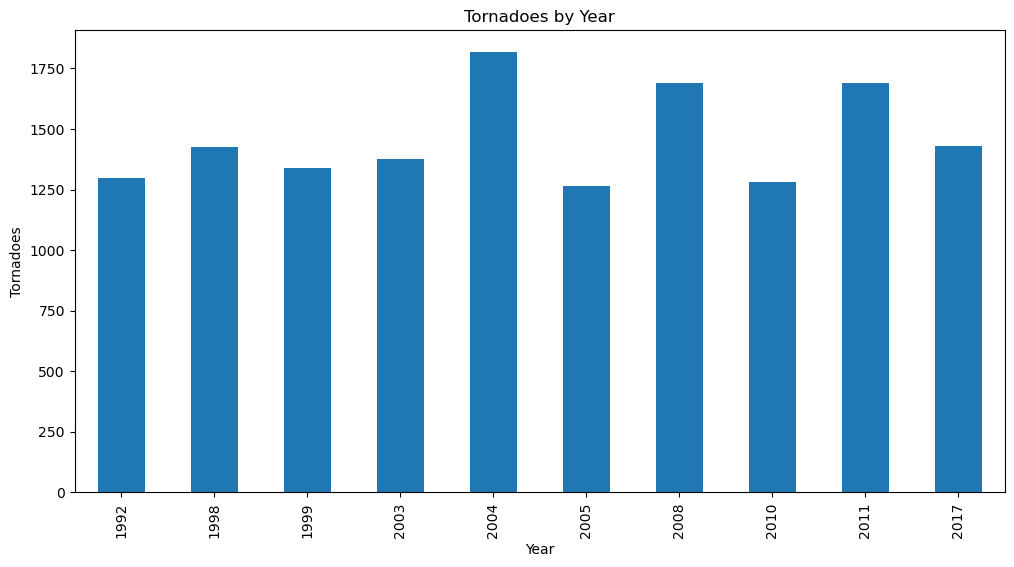

In [21]:
fig = plt.figure(figsize = (8, 6))
ax = tornados['yr'].value_counts().sort_values(ascending=False)[:10].sort_index().plot.bar(figsize=(12,6), title='Tornadoes by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Tornadoes')
# Save fig
fig.savefig('RubyTornPerYear.png')

### Scatter Plot

This scatter plot shows the number of fatalities compared to the number of injuries. 

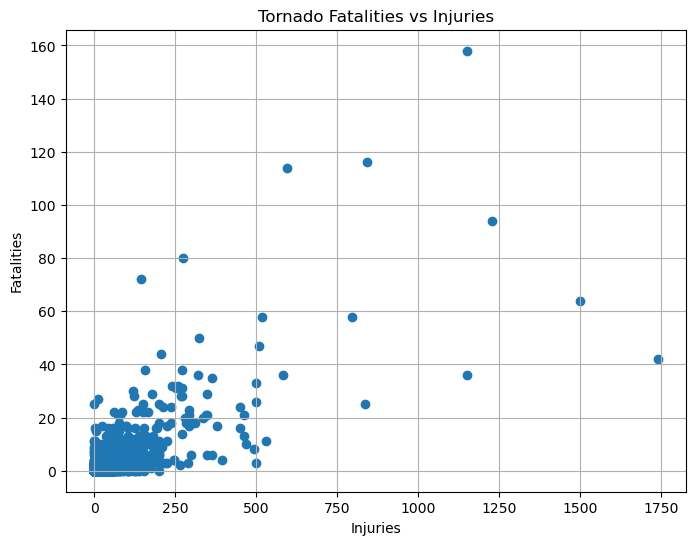

In [23]:
fig = plt.figure(figsize = (8, 6))
plt.scatter(tornados['inj'], tornados['fat'])
plt.title('Tornado Fatalities vs Injuries')
plt.xlabel('Injuries')
plt.ylabel('Fatalities')
plt.grid()
plt.show()
# Save fig
fig.savefig('RubyInjVFatal.png')

### Line Graph

This line graph shows the property lost ($) from tornadoes each year. (0 = unknown, 1 < 50, 2 = 50, 3 = 500 - 5000, 4 = 5000 - 50000, 5 = 50000 - 500000, 6 = 500000 - 5000000, 7 = 5000000 - 50000000, 8 = 50000000 - 500000000, 9 = 5000000000)

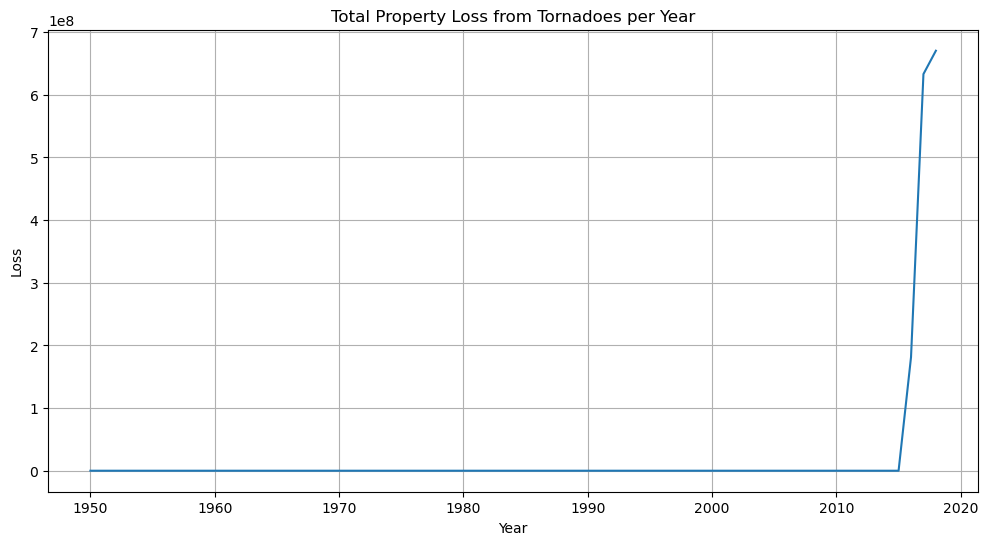

In [25]:
total_loss_by_year = tornados.groupby('yr')['loss'].sum()

fig = plt.figure(figsize=(12,6))
plt.plot(total_loss_by_year.index, total_loss_by_year.values)
plt.title('Total Property Loss from Tornadoes per Year')
plt.xlabel('Year')
plt.ylabel('Loss')
plt.grid()

plt.show()
# Save fig
fig.savefig('RubyPropLoss.png')

### Histogram

This histogram shows the frequency of each tornado magnitude. (-9 = unknown)

<Figure size 800x600 with 0 Axes>

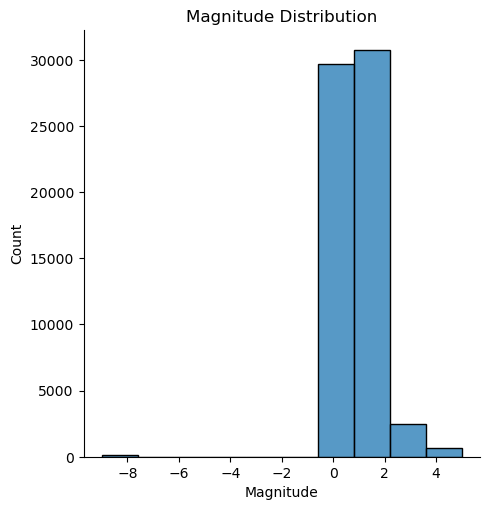

In [27]:
fig = plt.figure(figsize = (8, 6))
# Create histogram
sns.displot(tornados['mag'], kde = False, bins = 10)
# Labels
plt.xlabel('Magnitude')
plt.title('Magnitude Distribution')
plt.show()
# Save fig
fig.savefig('RubyMagDist.png')

### Box Plot

This box plot shows the tornado lengths per month. 

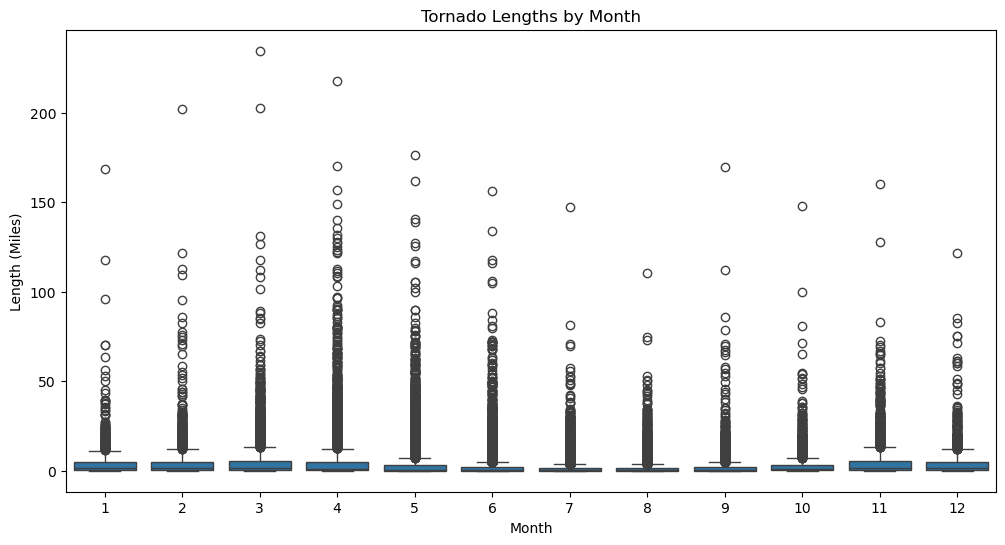

In [29]:
fig = plt.figure(figsize=(12,6))
sns.boxplot(x='mo', y='len', data=tornados)
plt.title('Tornado Lengths by Month')
plt.xlabel('Month')
plt.ylabel('Length (Miles)')
plt.show()
# Save fig
fig.savefig('RubyTornLengths.png')